# PID Control of Cancer Cell Population — Clearance Model + Drug

The **body's biology** is modeled as a PID controller $u$ acting on the death (clearance) rate — representing immune surveillance or endocrine signaling.

An external **drug** $v$ (constant dose) independently reduces the proliferation rate.

**Plant:**
$$\frac{dC}{dt} = \bigl(p - \alpha v - d_0 - k\,u\bigr)\,C$$

| Symbol | Meaning |
|--------|---------|
| $p$ | baseline proliferation rate |
| $\alpha$ | drug efficacy on proliferation |
| $v$ | drug dose (constant) |
| $d_0$ | natural death rate |
| $k$ | sensitivity of death rate to $u$ |

**PID controller** (body; reverse-acting: $K_p < 0$):
$$e = C_{sp} - C, \qquad \frac{dx_1}{dt} = e, \qquad u = K_p\!\left(e + \frac{x_1}{T_i} - T_d\frac{dC}{dt}\right)$$

**Resolving the implicit D-term** (with $p_{\text{eff}} = p - \alpha v$):
$$u = \frac{K_p\!\left(e + \dfrac{x_1}{T_i} - T_d\,(p_{\text{eff}} - d_0)\,C\right)}{1 - K_p\,T_d\,k\,C}$$

**Steady state:** $u_{ss} = (p_{\text{eff}} - d_0)/k$ — the drug reduces the clearance burden on the body's controller.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# --- Plant parameters ---
p     = 0.5  # baseline proliferation rate (1/day)
d0    = 0.2  # natural death rate (1/day)
k     = 1.0  # sensitivity of death rate to body's control signal u
C_sp  = 0.5  # setpoint: target cell density

# --- Drug (constant dose, acts on proliferation) ---
alpha = 0.5  # drug efficacy on proliferation rate
v     = 0.2  # drug dose (constant); set to 0 for no treatment

p_eff = p - alpha * v  # effective proliferation rate

# --- PID gains (Kp < 0: reverse-acting plant) ---
Kp    = -3.0 # proportional gain
Ti    = 10.0 # integral time constant (days)
Td    = 0.5  # derivative time constant (days)
u_max = 2.0  # maximum body clearance signal

# --- Initial conditions ---
C0   = 0.9   # initial cell density (above setpoint)
x1_0 = 0.0   # no initial integral history

print(f"p_eff = {p_eff:.3f},  u_ss = {(p_eff - d0) / k:.3f}")

p_eff = 0.400,  u_ss = 0.200


In [3]:
def compute_u(C, x1):
    e           = C_sp - C
    numerator   = Kp * (e + x1/Ti - Td * (p_eff - d0) * C)
    denominator = 1 - Kp * Td * k * C   # > 0 always since Kp < 0
    u           = numerator / denominator
    return float(np.clip(u, 0.0, u_max))

def odes(t, y):
    C, x1 = y
    u      = compute_u(C, x1)
    dC_dt  = (p_eff - d0 - k * u) * C
    dx1_dt = C_sp - C
    return [dC_dt, dx1_dt]

In [4]:
t_span = (0, 80)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(odes, t_span, [C0, x1_0], t_eval=t_eval)

t  = sol.t
C  = sol.y[0]
x1 = sol.y[1]
e  = C_sp - C
u  = np.array([compute_u(Ci, x1i) for Ci, x1i in zip(C, x1)])

# PID component breakdown
P_term = Kp * e
I_term = Kp * x1 / Ti
dC_dt  = np.gradient(C, t)
D_term = -Kp * Td * dC_dt

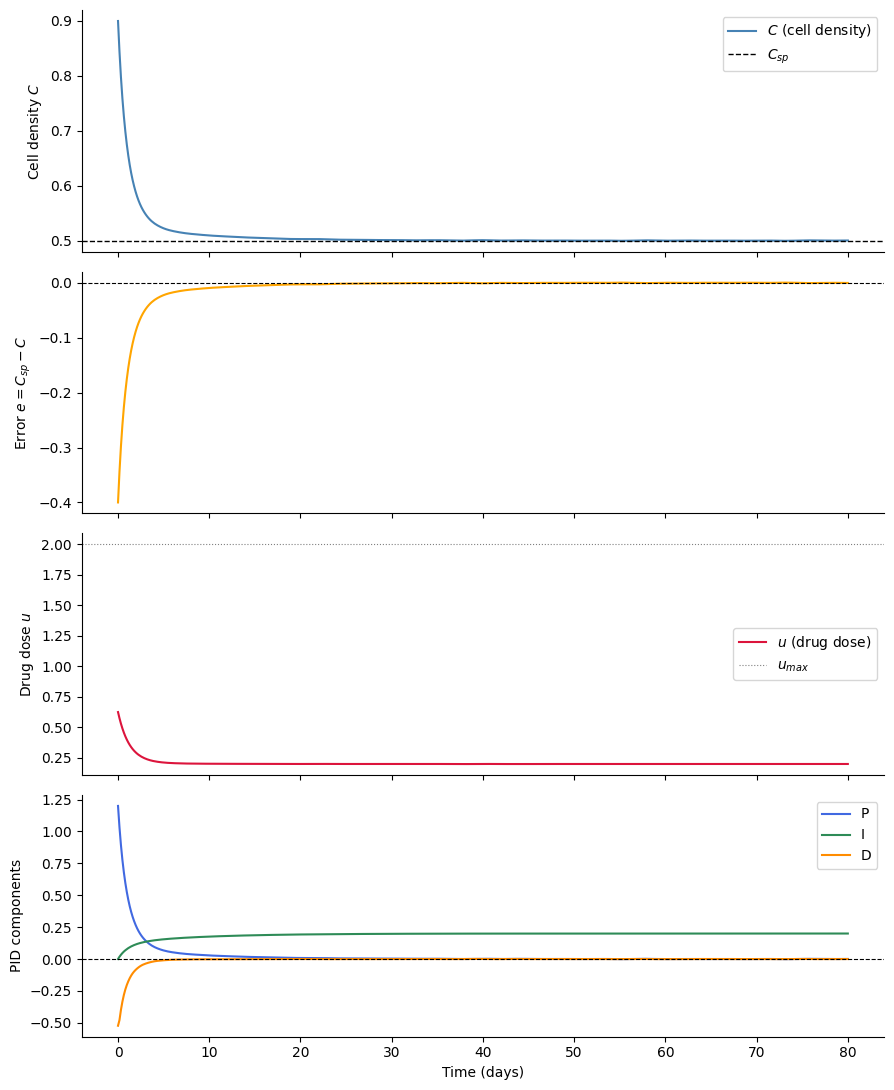

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

# --- Cell density ---
axes[0].plot(t, C, color='steelblue', label='$C$ (cell density)')
axes[0].axhline(C_sp, color='k', linestyle='--', linewidth=1.0, label='$C_{sp}$')
axes[0].set_ylabel('Cell density $C$')
axes[0].legend()

# --- Error ---
axes[1].plot(t, e, color='orange')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Error $e = C_{sp} - C$')

# --- Control input ---
axes[2].plot(t, u, color='crimson', label='$u$ (drug dose)')
axes[2].axhline(u_max, color='gray', linestyle=':', linewidth=0.8, label='$u_{max}$')
axes[2].set_ylabel('Drug dose $u$')
axes[2].legend()

# --- PID component breakdown ---
axes[3].plot(t, P_term, label='P', color='royalblue')
axes[3].plot(t, I_term, label='I', color='seagreen')
axes[3].plot(t, D_term, label='D', color='darkorange')
axes[3].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('PID components')
axes[3].set_xlabel('Time (days)')
axes[3].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pid_cancer_trajectories.pdf', bbox_inches='tight')
plt.show()

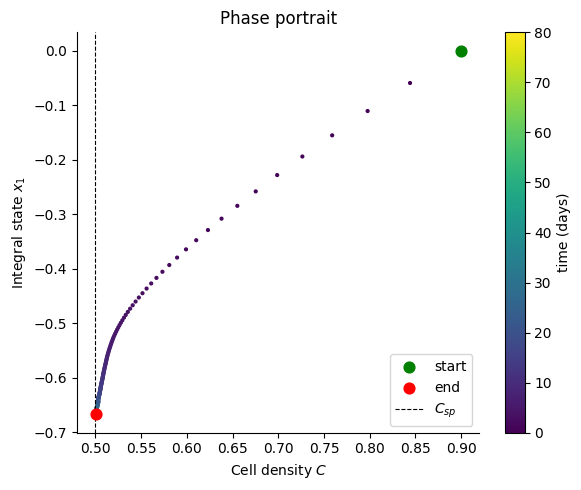

In [6]:
# Phase portrait: C vs x1 (integral state)
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(C, x1, c=t, cmap='viridis', s=4)
ax.scatter(C[0],  x1[0],  color='green', s=60, zorder=5, label='start')
ax.scatter(C[-1], x1[-1], color='red',   s=60, zorder=5, label='end')
ax.axvline(C_sp, color='k', linestyle='--', linewidth=0.8, label='$C_{sp}$')
ax.set_xlabel('Cell density $C$')
ax.set_ylabel('Integral state $x_1$')
ax.set_title('Phase portrait')
ax.legend()
plt.colorbar(sc, ax=ax, label='time (days)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pid_cancer_phase.pdf', bbox_inches='tight')
plt.show()

In [10]:
x = [14.535941276537688, 18.005976946079596, 21.26569821109125, 46.60744898477241, 49.97233758572965, 53.23205885074131, 54.809345948954814, 57.33299719915205, 60.80303286869393, 62.170005562377206, 63.64214559200604, 67.21732833013257, 69.53068544316055, 75.52437236289964, 80.36140099348573, 85.82931203557973, 88.87873916342208, 92.13846042843375, 95.50334902939099, 97.29095053213476, 99.39399324063244, 102.33825303252918, 104.23100160385759, 105.91343577065571]
y = [1.3850370218600188, 0.6925518804915839, 1.3850370218600188, 2.077588902351727, 9.69532589214353, 33.9335071442563, 81.02496610486776, 90.72022525788839, 122.57621023891612, 90.72022525788839, 51.24657002619176, 27.700873915447545, 11.080362914003672, 4.847662946071765, 4.155111065580181, 3.462625924211746, 7.6177369897919265, 7.6177369897919265, 9.69532589214353, 26.315770154464378, 44.32131817776827, 128.1163583263563, 236.8421316075486, 520.7756220670242]

x_cutoff = 61

## Model fitting to data

**Model:**
$$\frac{dC}{dt} = \bigl(g_0 + \sigma(u) - d(t)\bigr)\,C, \qquad \sigma(u) = \frac{K_{\max}\,u}{K_{1/2} + u}$$

- $g_0$: baseline net growth rate  
- $\sigma(u)$: Hill function — body's PI controller inhibits growth ($K_{\max} < 0$)  
- $d(t) = 0$ for $t < t_{\text{cut}}$, $d_{\text{drug}}$ after — external drug  
- PI controller: $e = C_{sp} - C$,\ $\dot{x}_1 = e$,\ $u = K_p(e + x_1/T_i)$,\ $u \ge 0$

**Two-part simulation:** integrate $[t_0, t_{\text{cut}}]$ with $d=0$, then $[t_{\text{cut}}, t_{\text{end}}]$ with $d=d_{\text{drug}}$, chaining the state at the cutoff.  
**Fit:** minimise mean squared log-error over the 24 data points.

In [ ]:
from scipy.optimize import differential_evolution

x_arr = np.array(x)
y_arr = np.array(y)

def sigma_hill(u, K_max, K_half):
    return K_max * u / (K_half + u)

def simulate(theta, dense=False):
    g0, K_max, K_half, Kp, Ti, C_sp, d_drug, C0 = theta

    def odes(t, y):
        C, x1 = y
        C   = max(C, 1e-12)
        e   = C_sp - C
        u   = max(Kp * (e + x1 / Ti), 0.0)
        d_t = d_drug if t >= x_cutoff else 0.0
        return [(g0 + sigma_hill(u, K_max, K_half) - d_t) * C, e]

    kw   = dict(dense_output=True, max_step=1.0, rtol=1e-5)
    sol1 = solve_ivp(odes, [x_arr[0], x_cutoff],  [C0, 0.0],            **kw)
    sol2 = solve_ivp(odes, [x_cutoff,  x_arr[-1]], sol1.sol(x_cutoff),   **kw)

    if dense:
        t1 = np.linspace(x_arr[0], x_cutoff,  300)
        t2 = np.linspace(x_cutoff,  x_arr[-1], 300)
        return (np.r_[t1, t2[1:]],
                np.r_[sol1.sol(t1)[0], sol2.sol(t2[1:])[0]])

    pre       = x_arr < x_cutoff
    C_out     = np.empty(len(x_arr))
    C_out[pre]  = sol1.sol(x_arr[pre])[0]
    C_out[~pre] = sol2.sol(x_arr[~pre])[0]
    return C_out

def objective(p):
    g0, K_max, lK_half, Kp, lTi, lC_sp, ld_drug, lC0 = p
    theta = [g0, K_max, np.exp(lK_half), Kp,
             np.exp(lTi), np.exp(lC_sp), np.exp(ld_drug), np.exp(lC0)]
    try:
        C_pred = simulate(theta)
        if np.any(C_pred <= 0) or not np.all(np.isfinite(C_pred)):
            return 1e10
        return np.mean((np.log(C_pred) - np.log(y_arr))**2)
    except Exception:
        return 1e10

In [ ]:
# Parameter bounds: [g0, K_max, log(K_half), Kp, log(Ti), log(C_sp), log(d_drug), log(C0)]
bounds = [
    (-0.1,  0.6),                            # g0
    (-3.0,  0.0),                            # K_max  (inhibitory Hill)
    (np.log(0.01), np.log(500)),             # log K_half
    (-20.0, -1e-3),                          # Kp     (reverse-acting)
    (np.log(0.5),  np.log(200)),             # log Ti
    (np.log(0.01), np.log(50)),              # log C_sp
    (np.log(0.01), np.log(5.0)),             # log d_drug
    (np.log(0.2),  np.log(10.0)),            # log C0
]

res = differential_evolution(
    objective, bounds, seed=42, maxiter=3000,
    tol=1e-9, popsize=20, polish=True, disp=False
)

p = res.x
g0_f, K_max_f = p[0], p[1]
K_half_f, Kp_f, Ti_f = np.exp(p[2]), p[3], np.exp(p[4])
C_sp_f, d_drug_f, C0_f = np.exp(p[5]), np.exp(p[6]), np.exp(p[7])

theta_fit = [g0_f, K_max_f, K_half_f, Kp_f, Ti_f, C_sp_f, d_drug_f, C0_f]
print(f"g0={g0_f:.4f}   K_max={K_max_f:.4f}   K_half={K_half_f:.3f}")
print(f"Kp={Kp_f:.4f}   Ti={Ti_f:.2f}   C_sp={C_sp_f:.4f}")
print(f"d_drug={d_drug_f:.4f}   C0={C0_f:.4f}")
print(f"Loss (mean log²): {res.fun:.6f}")

# --- Plot ---
t_dense, C_dense = simulate(theta_fit, dense=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(x_arr, y_arr, 'ko', ms=5, label='data')
ax.semilogy(t_dense, np.clip(C_dense, 1e-3, None), color='steelblue', label='fit')
ax.axvline(x_cutoff, color='crimson', lw=1, ls='--', label=f'drug start (t={x_cutoff})')
ax.set_xlabel('Time')
ax.set_ylabel('Cell count $C$')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pid_cancer_fit.pdf', bbox_inches='tight')
plt.show()